In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data=pd.read_csv("../training/memory_strength_dataset.csv")
data.head()

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,retention,S
0,56.312171,7,7.190609,7,85.791568,2,61.106404,114.327011
1,2.495917,1,8.053991,6,10.132390,3,98.713498,192.757354
2,24.313371,9,6.673295,9,59.508954,2,72.257539,74.825677
3,235.882474,6,4.193669,7,12.255043,0,0.247996,39.316935
4,138.330092,6,7.269977,8,15.846049,1,14.729763,72.223718


In [4]:
data.describe()

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,retention,S
count,2742.000000,2742.000000,2742.000000,2742.000000,2742.000000,2742.000000,2742.000000,2742.000000
mean,109.255261,4.630197,6.483838,5.419037,95.670145,1.489424,40.435491,86.322682
std,106.865882,2.877723,2.010541,2.868359,48.331076,1.125667,29.390903,91.915844
min,1.000000,0.000000,3.001229,1.000000,10.132390,0.000000,0.007534,7.620537
25%,32.596458,2.000000,4.769632,3.000000,53.527186,0.000000,13.838551,61.700081
50%,78.253506,5.000000,6.477841,5.000000,96.603610,1.000000,35.311158,80.494202
75%,150.481648,7.000000,8.227100,8.000000,137.538892,3.000000,65.571039,100.203073
max,720.000000,9.000000,9.991914,10.000000,179.978145,3.000000,99.903273,4149.620096


<Axes: >

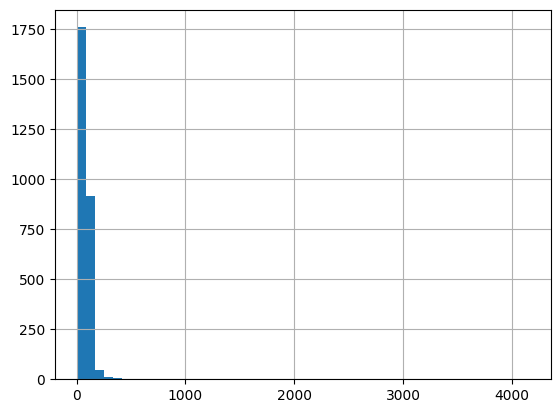

In [5]:
data["S"].hist(bins=50)

Actually if we inspect properly the mean is 86 and the max is 4000 which is such a huge outlier

In [7]:
print((data["S"]>300).sum())
print((data["S"]>500).sum())

16
4


Then we can remove the top 1%

<Axes: >

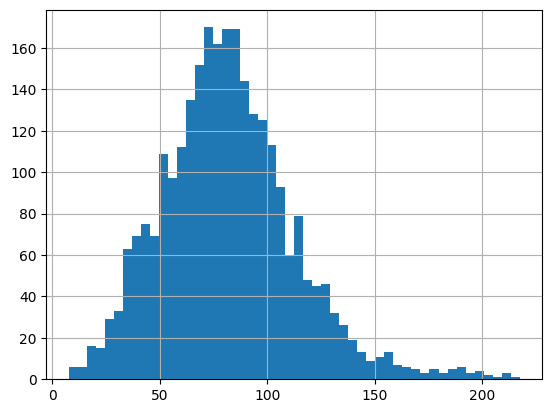

In [10]:
upper_limit=data["S"].quantile(0.99)
data_cleaned=data[data["S"]<=upper_limit]
data_cleaned["S"].hist(bins=50)

In [11]:
data_cleaned.describe()

,revision_timing,nth_revision,sleep_duration,topic_difficulty,study_duration,session_time,retention,S
count,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000,2714.000000
mean,108.825487,4.619749,6.482216,5.421518,95.666570,1.489683,40.044085,81.929597
std,103.653405,2.881080,2.009379,2.867371,48.410376,1.125093,29.045243,31.109380
min,1.000000,0.000000,3.001229,1.000000,10.132390,0.000000,0.007534,7.620537
25%,33.901581,2.000000,4.769632,3.000000,53.283676,0.000000,13.670281,61.369644
50%,78.978347,5.000000,6.477841,5.000000,96.603610,1.000000,35.098407,80.145203
75%,150.511817,7.000000,8.225245,8.000000,137.598188,3.000000,64.889344,99.284812
max,720.000000,9.000000,9.991914,10.000000,179.978145,3.000000,99.381776,217.586111


In [15]:
data_cleaned.isnull().sum()

revision_timing     0
nth_revision        0
sleep_duration      0
topic_difficulty    0
study_duration      0
session_time        0
retention           0
S                   0
dtype: int64

In [16]:
data_cleaned.to_csv("../training/memory_strength_dataset_cleaned_2.csv", index=False)